First we'll start with importing the appropriate libraries. We need to create a pandas dataframe so we import pandas and matplotlib will allow us to get a visual of the data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Next we need to load the dataset. We are going to be loading this directly from the UCI repository instead of saving it or uploading it to my personal GitHub repository

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"

From the documentation we know the column names so we can manually set this

In [3]:
columns = [
    "class","cap-shape","cap-surface","cap-color","bruises","odor",
    "gill-attachment","gill-spacing","gill-size","gill-color",
    "stalk-shape","stalk-root","stalk-surface-above-ring",
    "stalk-surface-below-ring","stalk-color-above-ring",
    "stalk-color-below-ring","veil-type","veil-color",
    "ring-number","ring-type","spore-print-color",
    "population","habitat"
]

mushrooms = pd.read_csv(url, header=None, names=columns)
mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Now we have all the columns sorted, so we'll pick the class column as this signifies whether the mushroom is edible or poisonious, the odor column. These two are specified and then I'll also choose the cap shape to analyze. 

We're going to also rename to easier to undertand names

In [4]:
mushrooms_subset = mushrooms[["class", "cap-shape", "odor"]].rename(
    columns={"class": "edible", "cap-shape": "cap_shape"}
    )
mushrooms_subset.head()

,edible,cap_shape,odor
0,p,x,p
1,e,x,a
2,e,b,l
3,p,x,p
4,e,x,n


Now we need to replace the code with numeric values for prepare for future processing

In [5]:
mushrooms_subset["edible"] = mushrooms_subset["edible"].map({"e": 0, "p": 1})

for col in ["cap_shape", "odor"]:
    mushrooms_subset[col] = mushrooms_subset[col].astype("category").cat.codes

mushrooms_subset.head()

,edible,cap_shape,odor
0,1,5,6
1,0,5,0
2,0,0,3
3,1,5,6
4,0,5,5


Now that we have the columns set we can look at the distrobution of data for each column

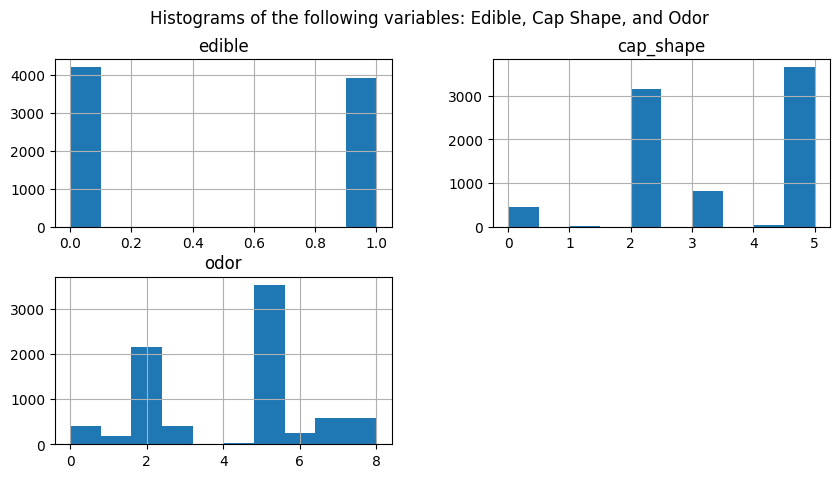

In [6]:
mushrooms_subset.hist(figsize=(10, 5))
plt.suptitle("Histograms of the following variables: Edible, Cap Shape, and Odor")
plt.show()

Next we'll create a scatterplot for each column to try and correlate how these tie into a mushroom being edible or poisonious

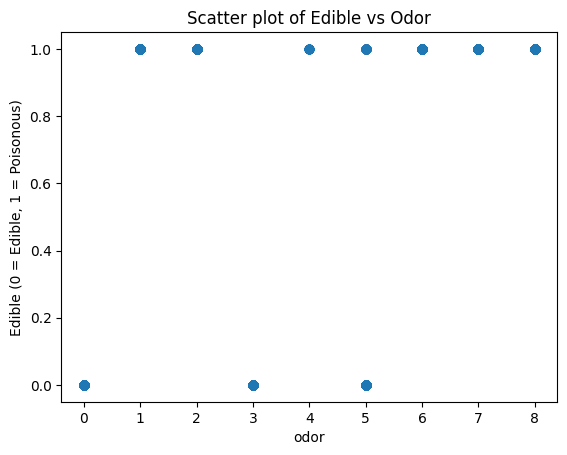

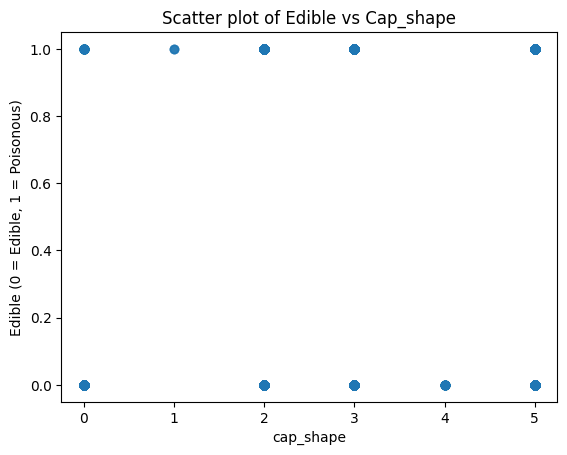

In [7]:
for col in ["odor", "cap_shape"]:
    plt.scatter(mushrooms_subset[col], mushrooms_subset["edible"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Edible (0 = Edible, 1 = Poisonous)")
    plt.title(f"Scatter plot of Edible vs {col.capitalize()}")
    plt.show()

In conlcusion to the scatterplot, I think odor may be a better comparision. I say this becasue there is less overlap in the data. Using cap shape, there is a lot of overlap.

With the odar chart we can see the values from 5-8 are almost all poisonious and a 50/50 chance for values 0-3.

For the cap cap since there is so much overlap, there doesnt seem to be a clear pattern so I would not think this a viable data comparison.